In [2]:
#Excercise 3.4
import pandas as pd

df = pd.read_csv(
    "../datasets/train/labels.csv"
)

print(df.head())
print(df.columns)

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False         True                 0   
1     10              False            True         True                14   
2     20               True            True         True                99   
3     30               True            True         True                99   
4     40               True            True         True               101   

   px_pedestrian  px_vehicle  
0              0          85  
1            301        1138  
2            196         517  
3            181         530  
4            169         538  
Index(['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle',
       'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')


In [3]:
import os
train_path = "../datasets/train/rgb-front"
test_path = "../datasets/test/rgb-front"
train_imgs = [
    f for f in os.listdir(train_path)
    if f.endswith(".jpg")
]

test_imgs = [
    f for f in os.listdir(test_path)
    if f.endswith(".jpg")
]

print(
    "Training images:",
    len(train_imgs)
)

print(
    "Test images:",
    len(test_imgs)
)

Training images: 7200
Test images: 3600



 has_traffic_light
has_traffic_light
True     5276
False    1924
Name: count, dtype: int64

Percentage:
has_traffic_light
True     73.28
False    26.72
Name: proportion, dtype: float64


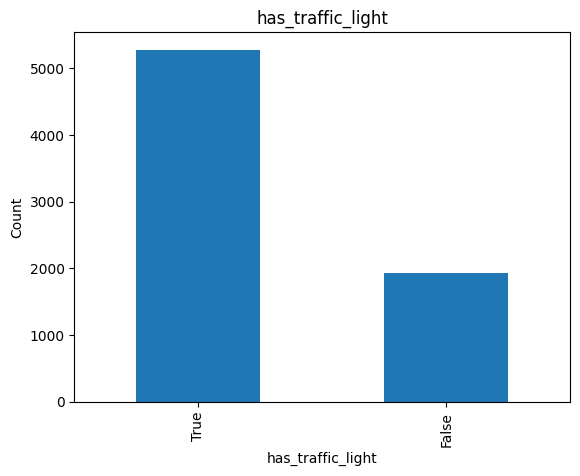


 has_pedestrian
has_pedestrian
False    5482
True     1718
Name: count, dtype: int64

Percentage:
has_pedestrian
False    76.14
True     23.86
Name: proportion, dtype: float64


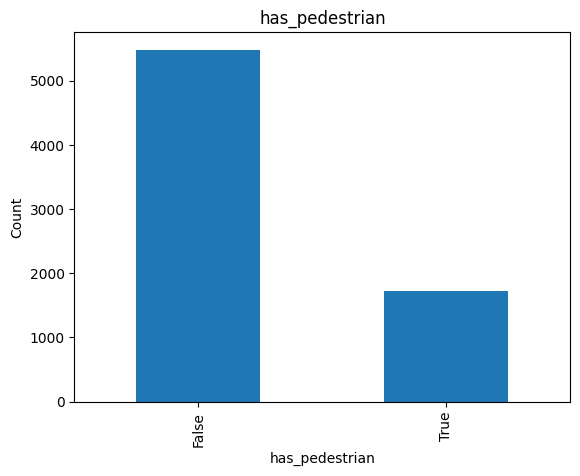


 has_vehicle
has_vehicle
True     5458
False    1742
Name: count, dtype: int64

Percentage:
has_vehicle
True     75.81
False    24.19
Name: proportion, dtype: float64


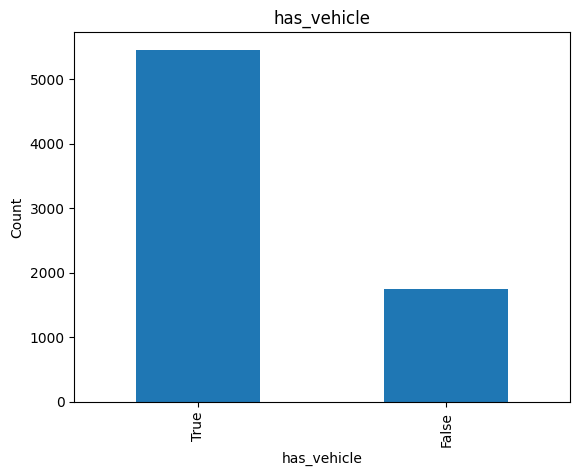

In [5]:
import os
import matplotlib.pyplot as plt

os.makedirs(
    "../results/excercise_3",
    exist_ok=True
)

for col in [
    "has_traffic_light",
    "has_pedestrian",
    "has_vehicle"
]:

    print("\n", col)

    print(
        df[col].value_counts()
    )

    print("\nPercentage:")

    print(
        round(
            df[col].value_counts(
                normalize=True
            ) * 100,
            2
        )
    )

    df[col].value_counts().plot(
        kind="bar"
    )

    plt.title(col)

    plt.ylabel("Count")

    plt.savefig(
        f"../results/excercise_3/{col}_distribution.png",
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

In [6]:
df["combo"] = (
    df["has_traffic_light"].astype(str)
    + "_"
    + df["has_pedestrian"].astype(str)
    + "_"
    + df["has_vehicle"].astype(str)
)

combo_counts = df["combo"].value_counts()

print(combo_counts)

combo
True_False_True      3040
True_True_True       1125
False_False_True     1063
True_False_False      832
False_False_False     547
True_True_False       279
False_True_True       230
False_True_False       84
Name: count, dtype: int64


In [7]:
import os

files = os.listdir(
    "../datasets/train/rgb-front"
)

print(files[:10])

['000000.jpg', '000010.jpg', '000020.jpg', '000030.jpg', '000040.jpg', '000050.jpg', '000060.jpg', '000070.jpg', '000080.jpg', '000090.jpg']


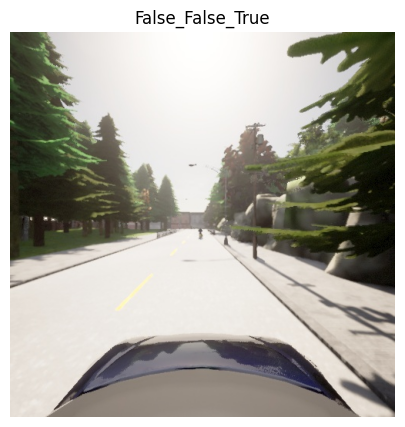

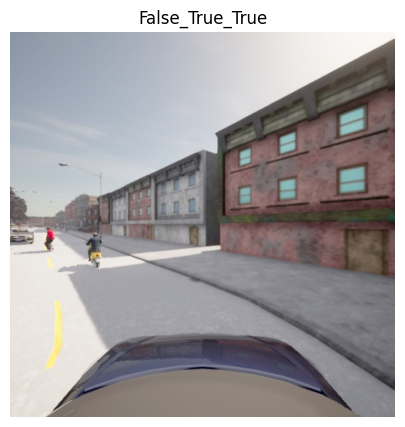

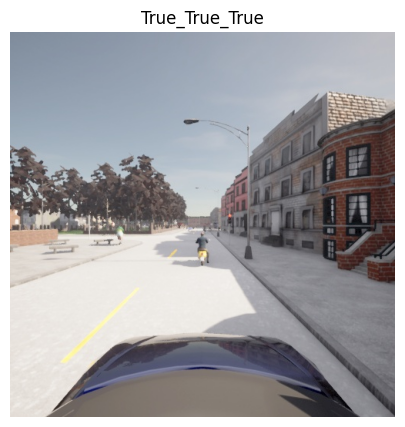

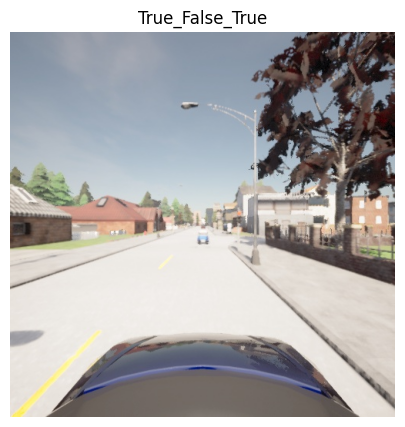

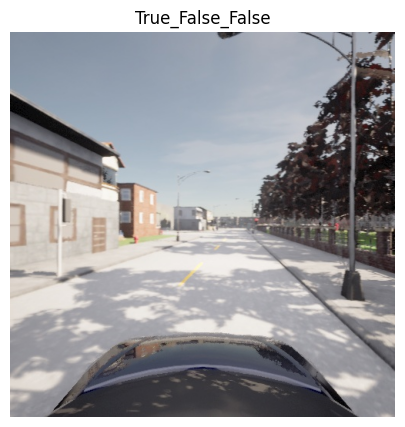

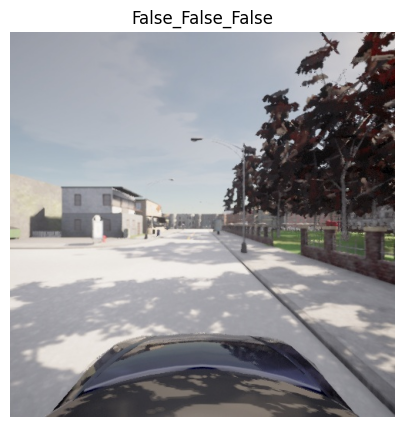

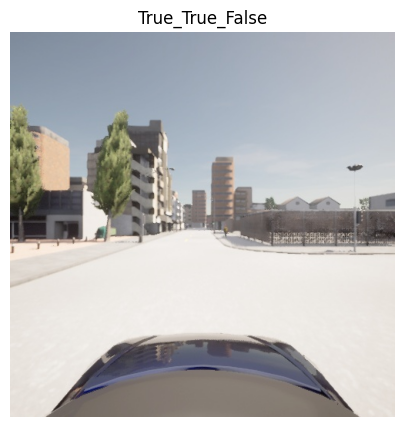

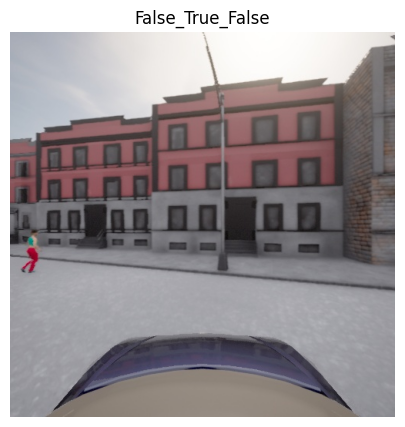

In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_path = "../datasets/train/rgb-front"

for combo in df["combo"].unique():

    sample = df[
        df["combo"] == combo
    ].iloc[0]

    frame = sample["frame"]

    filename = f"{frame:06d}.jpg"

    img = Image.open(
        os.path.join(
            image_path,
            filename
        )
    )

    plt.figure(figsize=(8,5))

    plt.imshow(img)

    plt.title(combo)

    plt.axis("off")

    plt.show()

In [9]:
#Excercise 3.5
print(df.head())

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False         True                 0   
1     10              False            True         True                14   
2     20               True            True         True                99   
3     30               True            True         True                99   
4     40               True            True         True               101   

   px_pedestrian  px_vehicle             combo  
0              0          85  False_False_True  
1            301        1138   False_True_True  
2            196         517    True_True_True  
3            181         530    True_True_True  
4            169         538    True_True_True  


In [10]:
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


In [11]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision import models
from PIL import Image
import pandas as pd
import os
import matplotlib.pyplot as plt

In [12]:
train_df = pd.read_csv(
    "../datasets/train/labels.csv"
)

val_df = pd.read_csv(
    "../datasets/validation/labels.csv"
)

In [13]:
class CarlaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        target
    ):

        self.df = dataframe

        self.image_dir = image_dir

        self.target = target

        self.transform = transforms.Compose([

            transforms.Resize((224,224)),

            transforms.ToTensor()

        ])


    def __len__(self):

        return len(self.df)


    def __getitem__(self,idx):

        row = self.df.iloc[idx]

        frame = row["frame"]

        filename = f"{frame:06d}.jpg"

        path = os.path.join(
            self.image_dir,
            filename
        )

        image = Image.open(path)

        image = self.transform(image)

        label = float(
            row[self.target]
        )

        return image,label

In [14]:
ped_train = CarlaDataset(
    train_df,
    "../datasets/train/rgb-front",
    "has_pedestrian"
)

ped_val = CarlaDataset(
    val_df,
    "../datasets/validation/rgb-front",
    "has_pedestrian"
)

train_loader = DataLoader(
    ped_train,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    ped_val,
    batch_size=32
)

print(len(train_loader))
print(len(val_loader))

225
113


In [15]:
# Pedestrian Detector
import torch.nn as nn

model = models.resnet18(
    weights="DEFAULT"
)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [16]:
criterion=nn.BCEWithLogitsLoss()

optimizer=torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [17]:
train_losses = []
val_losses = []

pedestrian_results = []

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.float().unsqueeze(1)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    train_losses.append(
        train_loss
    )

    model.eval()

    val_running = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.float().unsqueeze(1)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_running += loss.item()

    val_loss = val_running / len(val_loader)

    val_losses.append(
        val_loss
    )

    pedestrian_results.append(
        [
            epoch + 1,
            train_loss,
            val_loss
        ]
    )

    print(
        f"Epoch {epoch+1}: "
        f"Train={train_loss:.4f} "
        f"Val={val_loss:.4f}"
    )

Epoch 1: Train=0.5103 Val=0.7158
Epoch 2: Train=0.4183 Val=0.8414
Epoch 3: Train=0.3647 Val=0.6166
Epoch 4: Train=0.3144 Val=0.8701
Epoch 5: Train=0.2675 Val=0.7260


In [18]:
ped_train_losses = train_losses
ped_val_losses = val_losses

In [19]:
torch.save(
    model.state_dict(),
    "../models/pedestrian_model.pth"
)

print("Pedestrian model saved")

Pedestrian model saved


In [20]:
import pandas as pd

pd.DataFrame(
    pedestrian_results,
    columns=[
        "Epoch",
        "Train Loss",
        "Validation Loss"
    ]
).to_csv(
    "../results/excercise_3/pedestrian_training.csv",
    index=False
)

print("Pedestrian training CSV saved")

Pedestrian training CSV saved


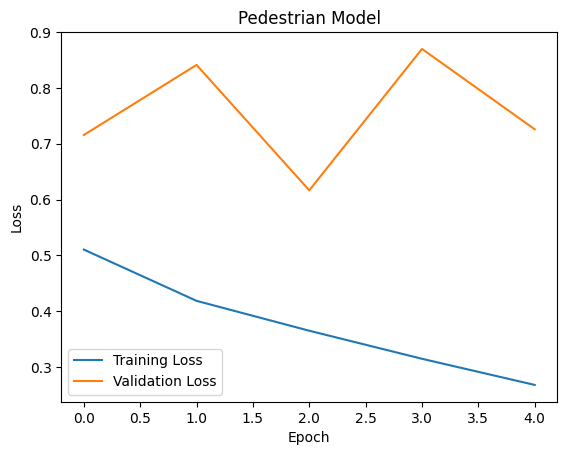

In [21]:
import matplotlib.pyplot as plt

plt.plot(
    ped_train_losses,
    label="Training Loss"
)

plt.plot(
    ped_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Pedestrian Model")

plt.legend()

plt.savefig(
    "../results/excercise_3/pedestrian_loss.png",
    bbox_inches="tight"
)

plt.show()

plt.close()

In [22]:
vehicle_train = CarlaDataset(
    train_df,
    "../datasets/train/rgb-front",
    "has_vehicle"
)

vehicle_val = CarlaDataset(
    val_df,
    "../datasets/validation/rgb-front",
    "has_vehicle"
)

train_loader = DataLoader(
    vehicle_train,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    vehicle_val,
    batch_size=64
)

In [23]:
import torch.nn as nn

model = models.resnet18(
    weights="DEFAULT"
)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model = model.to(device)

In [24]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [25]:
vehicle_train_losses = []
vehicle_val_losses = []

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.float().unsqueeze(1)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    vehicle_train_losses.append(
        train_loss
    )

    model.eval()

    val_running = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.float().unsqueeze(1)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_running += loss.item()

    val_loss = val_running / len(val_loader)

    vehicle_val_losses.append(
        val_loss
    )

    print(
        f"Epoch {epoch+1}: "
        f"Train={train_loss:.4f} "
        f"Val={val_loss:.4f}"
    )

Epoch 1: Train=0.3014 Val=0.3472
Epoch 2: Train=0.2087 Val=0.2975
Epoch 3: Train=0.1726 Val=0.3688
Epoch 4: Train=0.1587 Val=0.3142
Epoch 5: Train=0.1303 Val=0.4415


In [26]:
torch.save(
    model.state_dict(),
    "../models/vehicle_model.pth"
)

print("Vehicle model saved successfully")

Vehicle model saved successfully


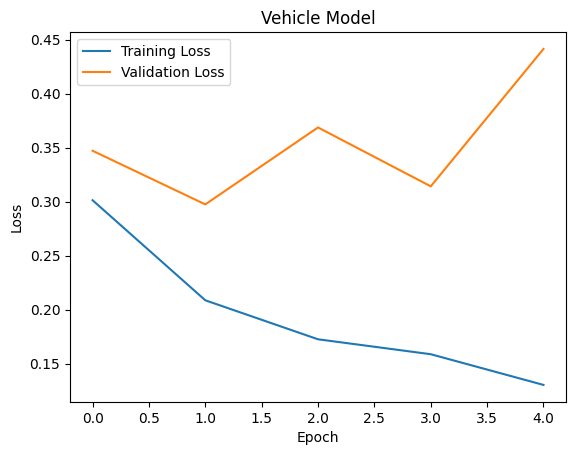

In [27]:
import matplotlib.pyplot as plt

plt.plot(
    vehicle_train_losses,
    label="Training Loss"
)

plt.plot(
    vehicle_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Vehicle Model")

plt.legend()

plt.savefig(
    "../results/excercise_3/vehicle_loss.png",
    bbox_inches="tight"
)

plt.show()

plt.close()

In [28]:
traffic_train = CarlaDataset(
    train_df,
    "../datasets/train/rgb-front",
    "has_traffic_light"
)

traffic_val = CarlaDataset(
    val_df,
    "../datasets/validation/rgb-front",
    "has_traffic_light"
)

train_loader = DataLoader(
    traffic_train,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    traffic_val,
    batch_size=64
)

In [29]:
import torch.nn as nn

model = models.resnet18(
    weights="DEFAULT"
)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model = model.to(device)

In [30]:
criterion=nn.BCEWithLogitsLoss()

optimizer=torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [31]:
#Training the traffic light model
traffic_train_losses = []
traffic_val_losses = []

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.float().unsqueeze(1)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    traffic_train_losses.append(
        train_loss
    )

    model.eval()

    val_running = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.float().unsqueeze(1)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_running += loss.item()

    val_loss = val_running / len(val_loader)

    traffic_val_losses.append(
        val_loss
    )

    print(
        f"Epoch {epoch+1}: "
        f"Train={train_loss:.4f} "
        f"Val={val_loss:.4f}"
    )

Epoch 1: Train=0.1716 Val=0.2396
Epoch 2: Train=0.0789 Val=0.0904
Epoch 3: Train=0.0551 Val=0.2512
Epoch 4: Train=0.0473 Val=0.0694
Epoch 5: Train=0.0311 Val=0.0987


In [32]:
torch.save(
    model.state_dict(),
    "../models/traffic_light_model.pth"
)

print("Traffic light model saved successfully")

Traffic light model saved successfully


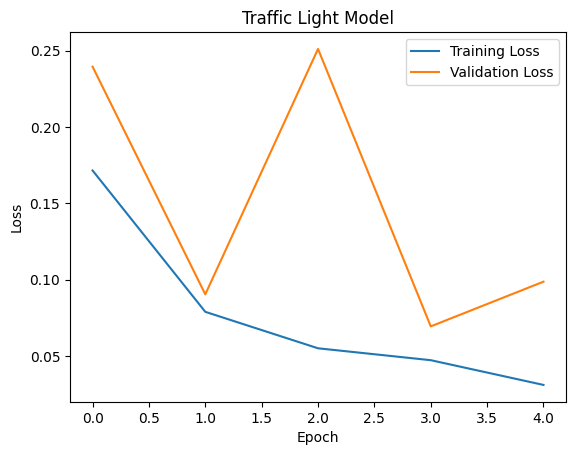

In [33]:
import matplotlib.pyplot as plt

plt.plot(
    traffic_train_losses,
    label="Training Loss"
)

plt.plot(
    traffic_val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Traffic Light Model")

plt.legend()

plt.savefig(
    "../results/excercise_3/traffic_light_loss.png",
    bbox_inches="tight"
)

plt.show()

plt.close()

In [34]:
#Excercise 3.6
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import numpy as np

In [35]:
ped_test = CarlaDataset(
    pd.read_csv(
        "../datasets/test/labels.csv"
    ),
    "../datasets/test/rgb-front",
    "has_pedestrian"
)

test_loader = DataLoader(
    ped_test,
    batch_size=64
)

In [36]:
model = models.resnet18(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model.load_state_dict(
    torch.load(
        "../models/pedestrian_model.pth"
    )
)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [37]:
predictions = []
true_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(
            outputs
        )

        preds = (
            probs > 0.5
        ).cpu().numpy()

        predictions.extend(
            preds
        )

        true_labels.extend(
            labels.numpy()
        )

predictions = np.array(
    predictions
).flatten()

true_labels = np.array(
    true_labels
)

ped_accuracy = accuracy_score(
    true_labels,
    predictions
)

ped_precision = precision_score(
    true_labels,
    predictions
)

ped_recall = recall_score(
    true_labels,
    predictions
)

ped_f1 = f1_score(
    true_labels,
    predictions
)

print(
    "Accuracy:",
    ped_accuracy
)

print(
    "Precision:",
    ped_precision
)

print(
    "Recall:",
    ped_recall
)

print(
    "F1:",
    ped_f1
)

Accuracy: 0.7163888888888889
Precision: 0.34782608695652173
Recall: 0.509915014164306
F1: 0.4135554279149914


In [38]:
# Eval for vehicles

vehicle_test = CarlaDataset(
    pd.read_csv(
        "../datasets/test/labels.csv"
    ),
    "../datasets/test/rgb-front",
    "has_vehicle"
)

test_loader = DataLoader(
    vehicle_test,
    batch_size=64
)

In [39]:
model = models.resnet18(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model.load_state_dict(
    torch.load(
        "../models/vehicle_model.pth"
    )
)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [40]:
predictions = []
true_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(
            outputs
        )

        preds = (
            probs > 0.5
        ).cpu().numpy()

        predictions.extend(
            preds
        )

        true_labels.extend(
            labels.numpy()
        )

predictions = np.array(
    predictions
).flatten()

true_labels = np.array(
    true_labels
)

vehicle_accuracy = accuracy_score(
    true_labels,
    predictions
)

vehicle_precision = precision_score(
    true_labels,
    predictions
)

vehicle_recall = recall_score(
    true_labels,
    predictions
)

vehicle_f1 = f1_score(
    true_labels,
    predictions
)

print(
    "Accuracy:",
    vehicle_accuracy
)

print(
    "Precision:",
    vehicle_precision
)

print(
    "Recall:",
    vehicle_recall
)

print(
    "F1:",
    vehicle_f1
)

Accuracy: 0.8194444444444444
Precision: 0.8241619228336496
Recall: 0.9651851851851851
F1: 0.8891163425452064


In [41]:
# Traffic Light eval

traffic_test = CarlaDataset(
    pd.read_csv(
        "../datasets/test/labels.csv"
    ),
    "../datasets/test/rgb-front",
    "has_traffic_light"
)

test_loader = DataLoader(
    traffic_test,
    batch_size=64
)

In [42]:
model = models.resnet18(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model.load_state_dict(
    torch.load(
        "../models/traffic_light_model.pth"
    )
)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [43]:
predictions = []
true_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(
            outputs
        )

        preds = (
            probs > 0.5
        ).cpu().numpy()

        predictions.extend(
            preds
        )

        true_labels.extend(
            labels.numpy()
        )

predictions = np.array(
    predictions
).flatten()

true_labels = np.array(
    true_labels
)

traffic_accuracy = accuracy_score(
    true_labels,
    predictions
)

traffic_precision = precision_score(
    true_labels,
    predictions
)

traffic_recall = recall_score(
    true_labels,
    predictions
)

traffic_f1 = f1_score(
    true_labels,
    predictions
)

print(
    "Accuracy:",
    traffic_accuracy
)

print(
    "Precision:",
    traffic_precision
)

print(
    "Recall:",
    traffic_recall
)

print(
    "F1:",
    traffic_f1
)

Accuracy: 0.9394444444444444
Precision: 0.9349264705882353
Recall: 0.9841331269349846
F1: 0.9588989441930619


In [44]:
#Saving the result values in a .csv file for reference
import pandas as pd
import os

rows = []

# Dataset Information
rows.append(["DATASET INFORMATION", ""])
rows.append(["Training Images", len(train_imgs)])
rows.append(["Test Images", len(test_imgs)])
rows.append(["", ""])

# Traffic Light Distribution
rows.append(["TRAFFIC LIGHT DISTRIBUTION", ""])

traffic_counts = df["has_traffic_light"].value_counts()
traffic_pct = round(
    df["has_traffic_light"].value_counts(normalize=True) * 100,
    2
)

for value in traffic_counts.index:
    rows.append(
        [
            f"{value}",
            f"{traffic_counts[value]} ({traffic_pct[value]}%)"
        ]
    )

rows.append(["", ""])

# Pedestrian Distribution
rows.append(["PEDESTRIAN DISTRIBUTION", ""])

ped_counts = df["has_pedestrian"].value_counts()
ped_pct = round(
    df["has_pedestrian"].value_counts(normalize=True) * 100,
    2
)

for value in ped_counts.index:
    rows.append(
        [
            f"{value}",
            f"{ped_counts[value]} ({ped_pct[value]}%)"
        ]
    )

rows.append(["", ""])

# Vehicle Distribution
rows.append(["VEHICLE DISTRIBUTION", ""])

vehicle_counts = df["has_vehicle"].value_counts()
vehicle_pct = round(
    df["has_vehicle"].value_counts(normalize=True) * 100,
    2
)

for value in vehicle_counts.index:
    rows.append(
        [
            f"{value}",
            f"{vehicle_counts[value]} ({vehicle_pct[value]}%)"
        ]
    )

rows.append(["", ""])

# Pedestrian Training
rows.append(["PEDESTRIAN TRAINING", ""])
rows.append(["Epoch", "Train Loss", "Validation Loss"])

for i in range(len(ped_train_losses)):
    rows.append(
        [
            i + 1,
            ped_train_losses[i],
            ped_val_losses[i]
        ]
    )

rows.append(["", ""])

# Vehicle Training
rows.append(["VEHICLE TRAINING", ""])
rows.append(["Epoch", "Train Loss", "Validation Loss"])

for i in range(len(vehicle_train_losses)):
    rows.append(
        [
            i + 1,
            vehicle_train_losses[i],
            vehicle_val_losses[i]
        ]
    )

rows.append(["", ""])

# Traffic Light Training
rows.append(["TRAFFIC LIGHT TRAINING", ""])
rows.append(["Epoch", "Train Loss", "Validation Loss"])

for i in range(len(traffic_train_losses)):
    rows.append(
        [
            i + 1,
            traffic_train_losses[i],
            traffic_val_losses[i]
        ]
    )

rows.append(["", ""])

# Pedestrian Metrics
rows.append(["PEDESTRIAN METRICS", ""])
rows.append(["Accuracy", ped_accuracy])
rows.append(["Precision", ped_precision])
rows.append(["Recall", ped_recall])
rows.append(["F1 Score", ped_f1])

rows.append(["", ""])

# Vehicle Metrics
rows.append(["VEHICLE METRICS", ""])
rows.append(["Accuracy", vehicle_accuracy])
rows.append(["Precision", vehicle_precision])
rows.append(["Recall", vehicle_recall])
rows.append(["F1 Score", vehicle_f1])

rows.append(["", ""])

# Traffic Light Metrics
rows.append(["TRAFFIC LIGHT METRICS", ""])
rows.append(["Accuracy", traffic_accuracy])
rows.append(["Precision", traffic_precision])
rows.append(["Recall", traffic_recall])
rows.append(["F1 Score", traffic_f1])

results_df = pd.DataFrame(rows)

results_df.to_csv(
    "../results/excercise_3/exercise3_results.csv",
    index=False,
    header=False
)

print(
    "exercise3_results.csv saved successfully"
)

exercise3_results.csv saved successfully
